# Day 20: Image Input Basics

Text in, text out. That's old AI. Today we add **images**.

Gemini is multimodal — it can see and understand images.

## Setup

In [30]:
from google import genai
from google.genai import types
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path='../.env')
API_KEY = os.environ["GEMINI_API_KEY"]
client = genai.Client(api_key=API_KEY)

In [31]:
response = client.models.generate_content(
    model='gemini-2.5-flash-lite',
    contents='Hi name is yash',
)
print(response.text)

Hi Yash! It's nice to meet you. How can I help you today?


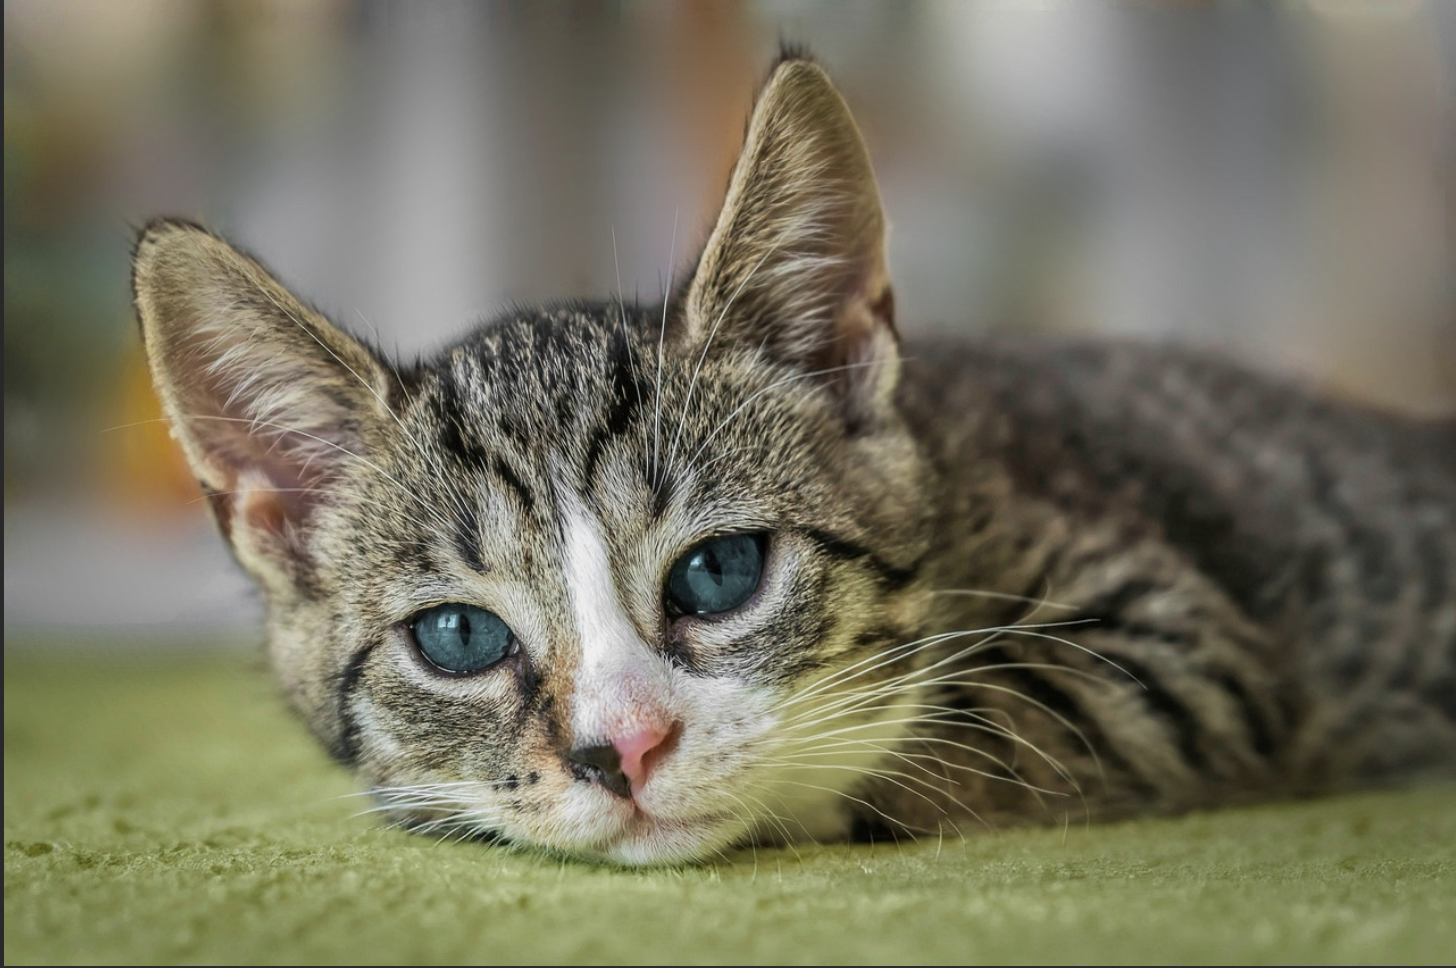

## Basic Image Input

Read image bytes, send to Gemini with a prompt.

In [32]:
# Read a local image
with open('sample.png', 'rb') as f:
    image_bytes = f.read()

# Send to Gemini
response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[
        types.Part.from_bytes(
            data=image_bytes,
            mime_type='image/jpeg',
        ),
        'What is in this image?'
    ]
)

print(response.text)

This image contains a cat.


## Helper Function

Let's create a reusable function for describing images.

In [33]:
def describe_image(image_path, prompt="What is in this image?"):
    """Send an image to Gemini and get a description."""
    # Determine mime type from extension
    ext = image_path.lower().split('.')[-1]
    mime_types = {
        'jpg': 'image/jpeg',
        'jpeg': 'image/jpeg',
        'png': 'image/png',
        'gif': 'image/gif',
        'webp': 'image/webp'
    }
    mime_type = mime_types.get(ext, 'image/jpeg')
    
    # Read image
    with open(image_path, 'rb') as f:
        image_bytes = f.read()
    
    # Send to Gemini
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=[
            types.Part.from_bytes(data=image_bytes, mime_type=mime_type),
            prompt
        ]
    )
    
    return response.text

In [34]:
# Test the helper function
result = describe_image('sample.png')
print(result)

This image features a **cute tabby kitten** with striking **blue eyes**.

Here are the details:
*   The kitten has a classic **tabby pattern** with stripes and swirls in shades of brown, grey, and black.
*   It has prominent **white fur** on its muzzle, chin, and a stripe between its eyes.
*   Its **nose is pink**, and it has long, delicate **white whiskers**.
*   The kitten is lying down, resting its head on a **green, textured surface**, which appears to be a rug or carpet.
*   The background is **softly blurred**, suggesting a shallow depth of field, and shows light, muted colors.
*   The kitten is looking directly at the camera with a calm and gentle expression.


## Different Prompts, Same Image

The prompt changes what you get back.

In [ ]:
prompts = [
    "What is in this image?",
    "Describe this image in one sentence.",
    "What colors are prominent in this image?",
    "What mood does this image convey?",
    "Is there any text in this image? If yes, what does it say?"
]

for prompt in prompts:
    answer = describe_image('sample.jpg', prompt)
    print(f"Q: {prompt}")
    print(f"A: {answer}\n")

## Multiple Images

You can send multiple images in one request.

In [ ]:
def compare_images(image_path1, image_path2, prompt="What are the differences between these two images?"):
    """Send two images to Gemini for comparison."""
    
    def read_image(path):
        ext = path.lower().split('.')[-1]
        mime_type = 'image/png' if ext == 'png' else 'image/jpeg'
        with open(path, 'rb') as f:
            return types.Part.from_bytes(data=f.read(), mime_type=mime_type)
    
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=[
            read_image(image_path1),
            read_image(image_path2),
            prompt
        ]
    )
    
    return response.text

# Test with two images (if you have them)
# result = compare_images('image1.jpg', 'image2.jpg')
# print(result)

## Key Takeaways

1. **Simple API** — Read bytes, send with `Part.from_bytes()`, add prompt
2. **Multimodal** — Images and text in the same request
3. **Prompts matter** — Different prompts get different insights from same image
4. **Multiple images** — Can compare or analyze multiple images at once

---

**Next:** Day 21 — Image + Text Prompting (advanced techniques)